In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#dataset loading
df = pd.read_excel('data/online_retail_II.xlsx' , sheet_name = 'Year 2010-2011')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.shape
df.info()
df.isnull().sum()
df['Country'].value_counts()


<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


Country
United Kingdom          495478
Germany                   9495
France                    8558
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [13]:
df = df.dropna(subset = ['Customer ID'])

df.shape
df.isnull().sum()


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [14]:
print(df[df['Invoice'].astype(str).str.startswith('C')].shape[0])

8905


In [15]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

df.shape

(397925, 8)

In [16]:
df["Total-price"] = df["Quantity"] * df["Price"]

In [20]:
import datetime as dt

reference_date = df['InvoiceDate'].max() + dt.timedelta(days = 1)

print(reference_date)

2011-12-10 12:50:00


In [24]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate' : lambda x : (reference_date - x.max()).days,
    'Invoice' : 'nunique',
    'Total-price' : 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.797166
std,100.009747,7.705493,8988.247836
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


In [25]:
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,3.830475,1.345478,6.592112
std,1.340215,0.683138,1.261411
min,0.693147,0.693147,0.000000
25%,2.944439,0.693147,5.730895
50%,3.951244,1.098612,6.515379
75%,4.962845,1.791759,7.416162
max,5.926926,5.351858,12.543284


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(rfm_scaled, columns= ['Recency', 'Frequency', 'Monetary'], index = rfm_log.index)
rfm_scaled.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,1.462236,-0.955013,3.696162
12347.0,-2.038611,1.074523,1.408754
12348.0,0.373310,0.386437,0.715512
12349.0,-0.622914,-0.955013,0.697817
12350.0,1.424800,-0.955013,-0.615880


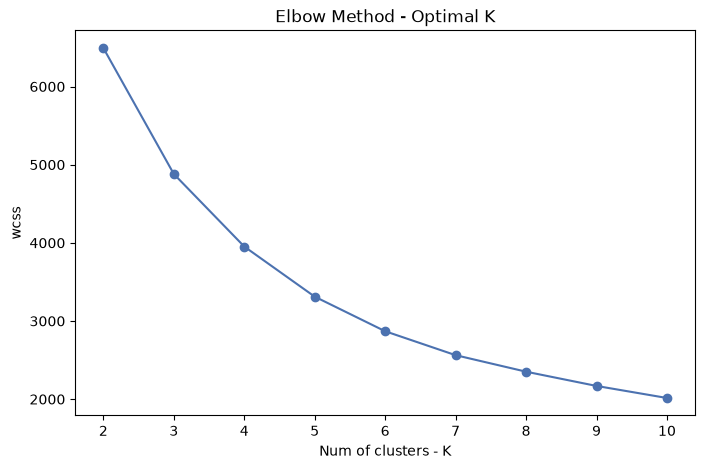

k=2: silhouette score = 0.4327
k=3: silhouette score = 0.3390
k=4: silhouette score = 0.3363
k=5: silhouette score = 0.3161
k=6: silhouette score = 0.3135
k=7: silhouette score = 0.3090
k=8: silhouette score = 0.3031
k=9: silhouette score = 0.2817
k=10: silhouette score = 0.2785


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
sil_score = []

for k in range(2,11):
    km = KMeans(n_clusters= k, random_state = 42, n_init = 10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)
    sil_score.append(silhouette_score(rfm_scaled, km.labels_))


#Elbow plot
plt.figure(figsize = (8,5))
plt.plot(range(2,11), wcss, marker= 'o', color = '#4C72B0')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Num of clusters - K')
plt.ylabel('wcss')
plt.tight_layout
plt.savefig('images/elbow_method.png', dpi=300)
plt.show()


for k , score in zip(range(2,11), sil_score):
    print(f"k={k}: silhouette score = {score:.4f}")

In [30]:
kmeans = KMeans(n_clusters = 4 , random_state = 42, n_init = 10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster').agg({
    'Recency' : 'mean',
    'Frequency' : 'mean',
    'Monetary' : 'mean'
}).round(1)

,Recency,Frequency,Monetary
Cluster,,,
0,18.7,2.1,538.3
1,12.1,13.6,8015.4
2,70.7,4.1,1791.1
3,184.0,1.3,342.4


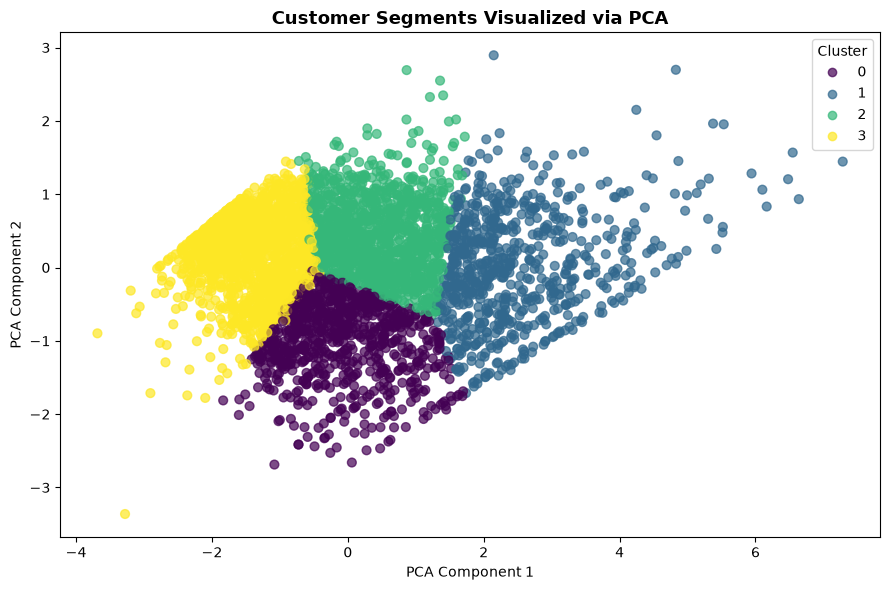

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize= (9,6))
scatter = plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'], cmap = 'viridis', s=40, alpha=0.7)
plt.title('Customer Segments Visualized via PCA', fontsize=13, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig('images/pca_clusters.png', dpi=200)
plt.show()

In [33]:
cluster_names = {
    1: 'Champions',
    0: 'New/Promising',
    2: 'At Risk',
    3: 'Lost/Dormant'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)
rfm['Segment'].value_counts()

Segment
Lost/Dormant     1594
At Risk          1183
New/Promising     839
Champions         723
Name: count, dtype: int64

In [34]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

rfm.to_csv('rfm_segments.csv')

print("Model, scaler, and segmented data saved!")


Model, scaler, and segmented data saved!
